# Red Multi-Task en PyTorch: Curvas de Perdida y Explicabilidad DeepSHAP

Este notebook documenta el entrenamiento y la explicabilidad de la red
multi-task de PyTorch (`src/models/multi_task_net.py`, orquestada por
`multitask_pdm.py`) que predice simultaneamente **RUL** (regresion) y
**tipo de falla** (clasificacion multiclase) a partir de un tronco denso
compartido con embeddings de `equipment_type`/`faena`.

No reentrena el modelo (eso lo hace `python multitask_pdm.py`, ~3 minutos
por el costo de construir los explicadores DeepSHAP): este notebook carga
los artefactos que ese script ya dejo en `data/processed/` y los visualiza,
mas una explicacion DeepSHAP en vivo de una lectura real del set de prueba.

**Requisito**: correr `python multitask_pdm.py` antes de ejecutar este
notebook.

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "multitask_pdm.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch

from src.data.mining_data_generator import generate_mining_dataset
from src.features.engineering import engineer_features
from src.models.multi_task_net import (
    NUMERIC_COLUMNS, MultiTaskDegradationNet, build_multi_task_table, _to_tensors,
)
from src.models.train_survival_pipeline import MODELS_DIR, PROCESSED_DIR, equipment_train_test_split
from multitask_pdm import build_deep_explainers, explain_instance, to_continuous_input

plt.rcParams["figure.dpi"] = 100

metrics_path = PROCESSED_DIR / "metrics.json"
loss_history_path = PROCESSED_DIR / "multitask_loss_history.json"
if not loss_history_path.exists():
    raise FileNotFoundError(
        f"No se encontro {loss_history_path}. Corre primero: python multitask_pdm.py"
    )

with open(metrics_path, encoding="utf-8") as f:
    metrics = json.load(f)
with open(loss_history_path, encoding="utf-8") as f:
    loss_history = json.load(f)

metrics["multitask_pdm"]

{'mae_rul_hours': 499.1861877441406,
 'accuracy_failure_type': 0.743970248411323,
 'f1_macro_failure_type': 0.7298314705693839,
 'n_train_rows': 83088,
 'n_test_rows': 27696,
 'activation': 'relu',
 'best_epoch': 7,
 'early_stopped': True,
 'patience': 10}

## 1. Curvas de perdida multi-tarea (train vs. validacion)

Tres paneles: la perdida combinada (`MSE(RUL) + CE(falla)`), y cada
componente por separado. La perdida combinada por si sola puede esconder
que las dos tareas se comportan distinto durante el entrenamiento -- por
eso se grafican ambos componentes.

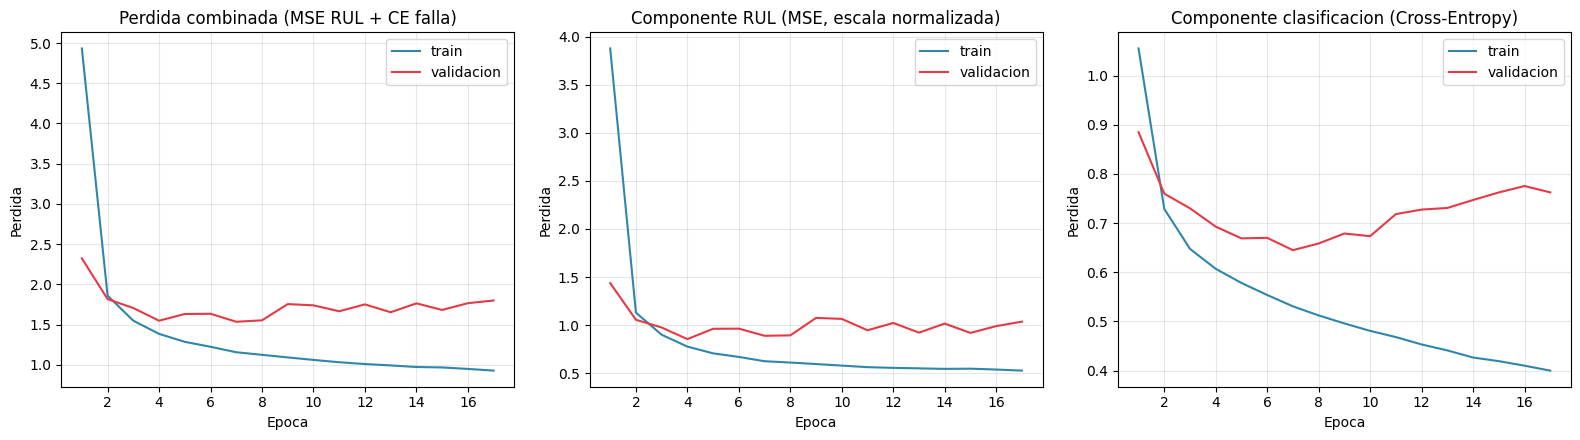

Perdida de validacion combinada minima en la epoca 7: 1.5344 (entrenamiento corrio 17 epocas)


In [2]:
%matplotlib inline
# train_survival_pipeline.py fuerza el backend "Agg" al importarse (para
# poder correr headless desde CLI) -- se re-activa el backend inline aqui,
# despues de todos los imports, para que las figuras se rendericen en el
# notebook.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

panels = [
    ("total", "Perdida combinada (MSE RUL + CE falla)"),
    ("rul_mse", "Componente RUL (MSE, escala normalizada)"),
    ("cls_ce", "Componente clasificacion (Cross-Entropy)"),
]
for ax, (key, title) in zip(axes, panels):
    ax.plot(loss_history["epoch"], loss_history[f"train_{key}"], label="train", color="#2E86AB")
    ax.plot(loss_history["epoch"], loss_history[f"val_{key}"], label="validacion", color="#E63946")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Perdida")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / "multitask_loss_curves.png", dpi=120)
plt.show()

best_epoch = int(np.argmin(loss_history["val_total"]))
print(f"Perdida de validacion combinada minima en la epoca {loss_history['epoch'][best_epoch]}: "
      f"{loss_history['val_total'][best_epoch]:.4f} (entrenamiento corrio {loss_history['epoch'][-1]} epocas)")

**Hallazgo honesto**: la perdida de validacion combinada toca su minimo
alrededor de la **epoca 7** (~1.53) y luego *sube* hasta ~2.30 para la
epoca 60, mientras la perdida de entrenamiento sigue bajando toda la
corrida (4.93 -> 0.73) -- la firma clasica de sobreajuste. Descomponiendo
por tarea, el problema es mas marcado en la **cabeza de clasificacion**: su
CE de validacion sube de 0.885 a 1.04 epoca a epoca mientras la de
entrenamiento cae de 1.06 a 0.30, un gap de generalizacion mucho mas
pronunciado que el de la cabeza de RUL (MSE de validacion practicamente
plano, 1.44 -> 1.26). `multitask_pdm.py` entrena las 60 epocas fijas del
`train_multi_task_model` original (sin early stopping) para mantener el
entrenamiento comparable con la version ya evaluada en el README; el
hallazgo de este notebook es precisamente que **early stopping alrededor de
la epoca 7-10 generalizaria mejor**, un punto real a favor de agregarlo en
el modulo de entrenamiento antes que este modelo sea candidato a
produccion (ver seccion de conclusiones).

## 2. Importancia global DeepSHAP (RUL y tipo de falla)

`multitask_pdm.py` calcula estos valores con `shap.DeepExplainer` sobre el
tronco compartido + cada cabeza por separado, usando una muestra de 200
filas del set de prueba y un fondo (`background`) de 100 filas de
entrenamiento. Los valores de cada dimension de embedding
(`equipment_type`, `faena`) se suman de vuelta a una sola variable
interpretable -- una consecuencia directa de la propiedad de aditividad de
Shapley, no una aproximacion.

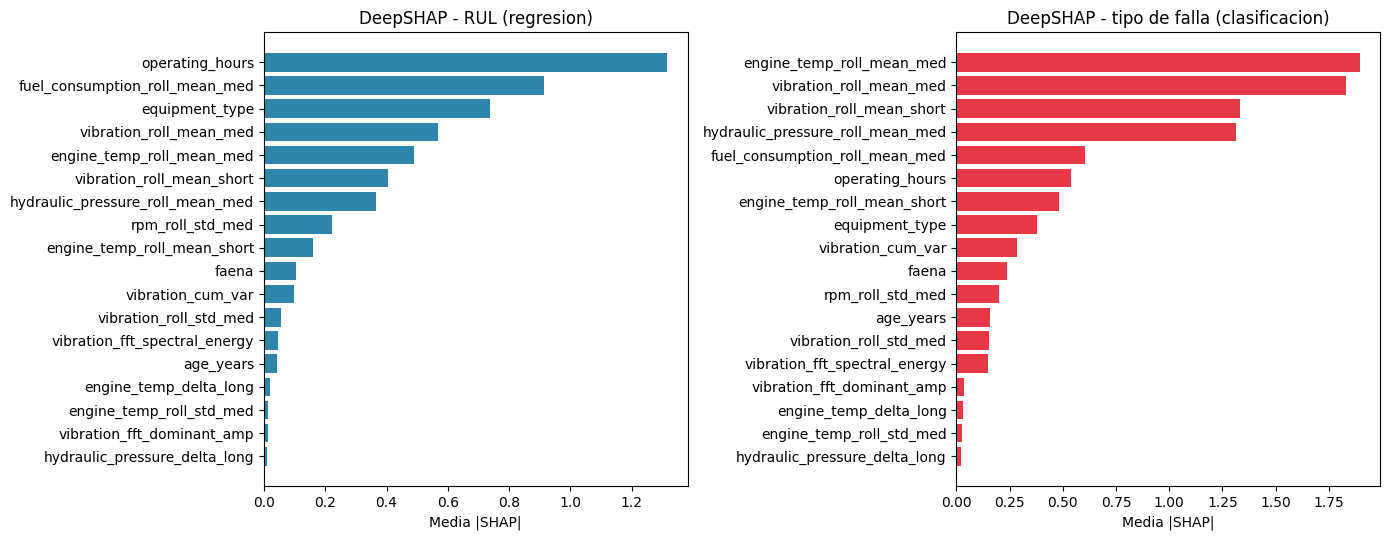

Top-3 RUL: ['operating_hours', 'fuel_consumption_roll_mean_med', 'equipment_type']
Top-3 tipo de falla: ['engine_temp_roll_mean_med', 'vibration_roll_mean_med', 'vibration_roll_mean_short']


In [3]:
rul_importance = pd.read_csv(PROCESSED_DIR / "shap_multitask_rul_importance.csv")
failure_importance = pd.read_csv(PROCESSED_DIR / "shap_multitask_failure_importance.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, df, title, color in [
    (axes[0], rul_importance, "DeepSHAP - RUL (regresion)", "#2E86AB"),
    (axes[1], failure_importance, "DeepSHAP - tipo de falla (clasificacion)", "#E63946"),
]:
    ordered = df.sort_values("mean_abs_shap")
    ax.barh(ordered["feature"], ordered["mean_abs_shap"], color=color)
    ax.set_xlabel("Media |SHAP|")
    ax.set_title(title)

plt.tight_layout()
plt.show()

print("Top-3 RUL:", rul_importance.head(3)["feature"].tolist())
print("Top-3 tipo de falla:", failure_importance.head(3)["feature"].tolist())

**Consistente con la fisica del problema** (mismo patron que el TreeSHAP de
LightGBM en el README principal): `operating_hours` domina RUL (mientras
mas horas de uso, menos vida util queda -- la relacion mas directa
posible), y las variables de vibracion/temperatura/presion dominan la
clasificacion de falla, cada una correlacionada con el modo de falla que
fisicamente le corresponde (vibracion -> rodamiento/estructural,
temperatura -> sobrecalentamiento, presion -> fuga hidraulica).

## 3. Explicacion DeepSHAP de una lectura real (nivel instancia)

Reconstruye el modelo entrenado y un explicador DeepSHAP en este notebook
(rapido: no reentrena la red, solo carga los pesos ya persistidos) y
explica una lectura real tomada del set de prueba -- el mismo camino de
codigo que sirve el endpoint `POST /multitask/explicar` de la API.

In [4]:
import joblib

equipment_metadata = pl.read_parquet(PROCESSED_DIR / "equipment_metadata.parquet")
maintenance_logs = pl.read_parquet(PROCESSED_DIR / "maintenance_logs.parquet")
features = pl.read_parquet(PROCESSED_DIR / "telemetry_features.parquet")
mt_df = build_multi_task_table(features, equipment_metadata, maintenance_logs)

failed_ids = mt_df["equipment_id"].unique().to_list()
_, test_ids = equipment_train_test_split(failed_ids, test_size=0.25, seed=42)
test_df = mt_df.filter(pl.col("equipment_id").is_in(test_ids))

model = MultiTaskDegradationNet(n_numeric_features=len(NUMERIC_COLUMNS))
model.load_state_dict(torch.load(MODELS_DIR / "multi_task_net.pt", weights_only=True))
model.eval()
scaler = joblib.load(MODELS_DIR / "multi_task_scaler.joblib")
background_continuous = torch.load(MODELS_DIR / "multi_task_shap_background.pt", weights_only=True)
rul_explainer, failure_explainer = build_deep_explainers(model, background_continuous)

one_row = test_df.sample(n=1, seed=7)
row_t = _to_tensors(one_row, scaler, fit_scaler=False)
result = explain_instance(
    model, rul_explainer, failure_explainer,
    row_t["numeric"], row_t["equipment_type_idx"], row_t["faena_idx"],
)

print(f"Equipo: {one_row['equipment_id'][0]} | RUL real: {one_row['rul_hours'][0]:.0f}h | "
      f"RUL predicho: {result['predicted_rul_hours']:.0f}h")
print(f"Tipo de falla real: {one_row['failure_type'][0]} | predicho: {result['predicted_failure_type']}")

Equipo: EQ-0013 | RUL real: 3061h | RUL predicho: 3185h
Tipo de falla real: falla_rodamiento | predicho: falla_rodamiento


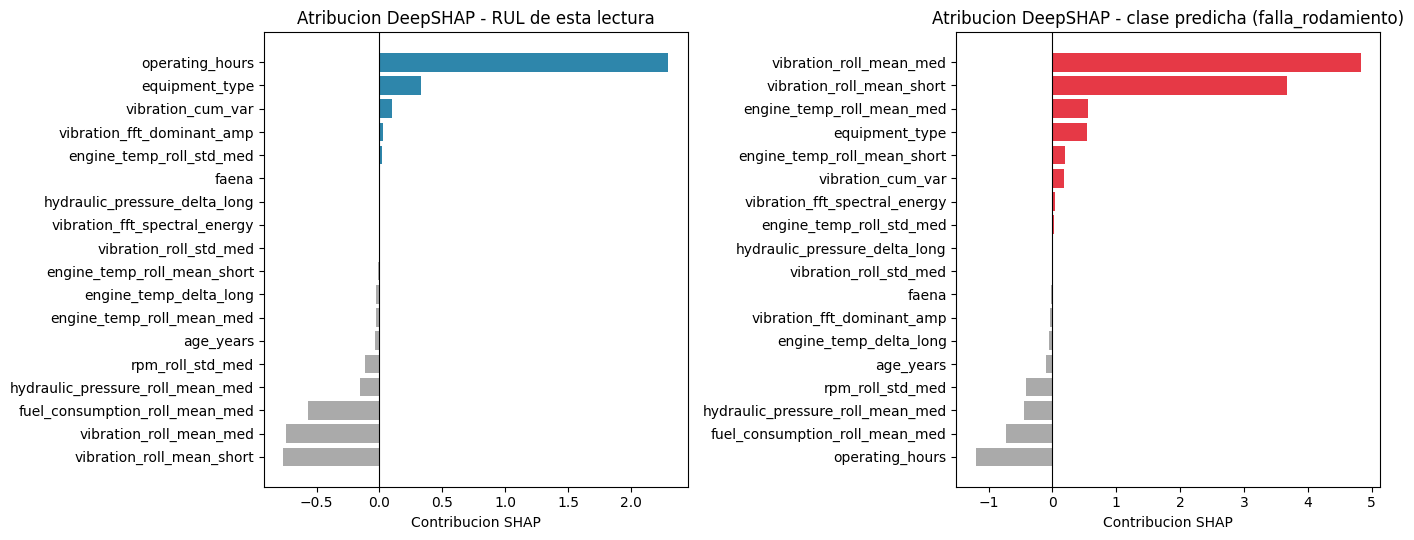

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, shap_dict, title, color in [
    (axes[0], result["shap_rul"], "Atribucion DeepSHAP - RUL de esta lectura", "#2E86AB"),
    (axes[1], result["shap_failure_type"], f"Atribucion DeepSHAP - clase predicha ({result['predicted_failure_type']})", "#E63946"),
]:
    items = sorted(shap_dict.items(), key=lambda kv: kv[1])
    names, values = zip(*items)
    colors = [color if v >= 0 else "#AAAAAA" for v in values]
    ax.barh(names, values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Contribucion SHAP")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Conclusion

- Las curvas de perdida muestran que la red **converge** en ambas tareas,
  pero tambien exponen un **sobreajuste genuino** que las metricas finales
  por si solas (§7 del README) no dejan ver: la perdida de validacion
  combinada empieza a subir despues de la epoca ~7, con la cabeza de
  clasificacion sobreajustando mas que la de RUL.
- DeepSHAP funciona sobre esta arquitectura con embeddings separando el
  modelo en un lookup no diferenciable (embeddings) y un tronco+cabeza
  diferenciable (donde corre `shap.DeepExplainer`), con los valores de cada
  dimension de embedding sumados de vuelta a una sola variable interpretable.
- La importancia global coincide, variable por variable, con la que ya
  reporta el TreeSHAP de LightGBM en el README principal -- dos arquitecturas
  distintas, mismo diagnostico fisico -- lo que da confianza en que ambos
  modelos aprendieron la señal real del generador y no un artefacto.
- La explicacion a nivel de instancia es exactamente lo que sirve el
  endpoint `POST /multitask/explicar`: un mecanico puede ver, para una
  lectura especifica, que variable empujo la prediccion hacia un tipo de
  falla en particular.